In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

print(" Libraries imported successfully")

 Libraries imported successfully


In [ ]:
base_path = '/content/drive/MyDrive/Machine Learning/Anomally detection/'

tr_data = pd.read_csv(base_path + 'tr_server_data.csv')   # Training data
cv_data = pd.read_csv(base_path + 'cv_server_data.csv')   # Validation data
gt_data = pd.read_csv(base_path + 'gt_server_data.csv')   # Ground truth labels

print(" Datasets loaded!")
print(f"Training data shape   : {tr_data.shape}")
print(f"Validation data shape : {cv_data.shape}")
print(f"Ground truth shape    : {gt_data.shape}")

 Datasets loaded!
Training data shape   : (306, 2)
Validation data shape : (306, 2)
Ground truth shape    : (306, 1)


In [ ]:
print(tr_data.head())
print(tr_data.dtypes)
print(tr_data.isnull().sum())
print(tr_data.describe())

   13.047  14.741
0  13.409  13.763
1  14.196  15.853
2  14.915  16.174
3  13.577  14.043
4  13.922  13.406
13.047    float64
14.741    float64
dtype: object
13.047    0
14.741    0
dtype: int64
           13.047      14.741
count  306.000000  306.000000
mean    14.115734   14.998513
std      1.356821    1.311758
min      4.752600    4.126200
25%     13.408250   14.360500
50%     14.060500   15.023000
75%     14.686750   15.656250
max     23.340000   24.350000


=== GROUND TRUTH LABELS ===
   0
0  0
1  0
2  0
3  0
4  0
5  0
6  0
7  0
8  1
9  0

Label Distribution:
0
0    297
1      9
Name: count, dtype: int64


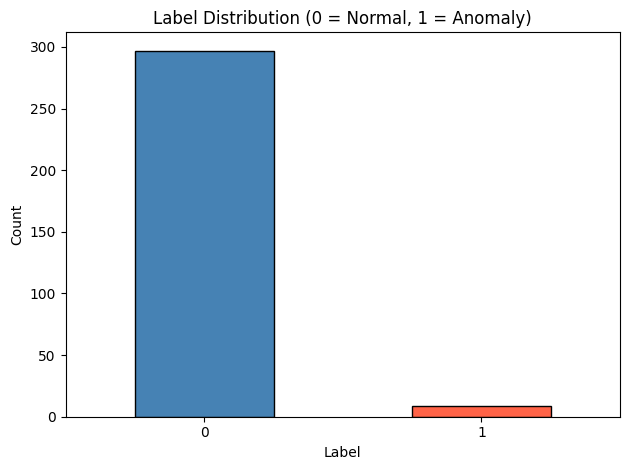

In [ ]:
print("=== GROUND TRUTH LABELS ===")
print(gt_data.head(10))

print("\nLabel Distribution:")
print(gt_data.iloc[:, 0].value_counts())

gt_data.iloc[:, 0].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black'
)
plt.title('Label Distribution (0 = Normal, 1 = Anomaly)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
tr_numeric = tr_data.select_dtypes(include=[np.number])
cv_numeric = cv_data.select_dtypes(include=[np.number])
tr_numeric.fillna(tr_numeric.mean(), inplace=True)
cv_numeric.fillna(cv_numeric.mean(), inplace=True)
y_true = gt_data.iloc[:len(cv_numeric), 0].values

print(f"Features ready!")
print(f"Training samples   : {tr_numeric.shape}")
print(f"Validation samples : {cv_numeric.shape}")
print(f"Labels             : {len(y_true)}")
print(f"Anomalies in val   : {np.sum(y_true == 1)}")
print(f"Normal in val      : {np.sum(y_true == 0)}")

Features ready!
Training samples   : (306, 2)
Validation samples : (306, 2)
Labels             : 306
Anomalies in val   : 9
Normal in val      : 297


In [ ]:
y_train = np.zeros(len(tr_numeric))
X_train = tr_numeric.values
X_val   = cv_numeric.values
scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print("Scaling complete!")
print(f"X_train shape : {X_train_scaled.shape}")
print(f"X_val shape   : {X_val_scaled.shape}")

Scaling complete!
X_train shape : (306, 2)
X_val shape   : (306, 2)


In [ ]:
X_combined = np.vstack([X_train_scaled, X_val_scaled])
y_combined = np.concatenate([y_train, y_true])

print(f"Combined dataset shape : {X_combined.shape}")
print(f"Total Normal samples   : {np.sum(y_combined == 0)}")
print(f"Total Anomaly samples  : {np.sum(y_combined == 1)}")

Combined dataset shape : (612, 2)
Total Normal samples   : 603
Total Anomaly samples  : 9


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_combined, y_combined)
print("Random Forest model trained!")
print(f"Number of trees : {rf_model.n_estimators}")
print(f"Features used   : {rf_model.n_features_in_}")

Random Forest model trained!
Number of trees : 100
Features used   : 2


In [ ]:
y_pred = rf_model.predict(X_val_scaled)

y_prob = rf_model.predict_proba(X_val_scaled)[:, 1]

print(f"Total Validation Samples : {len(y_pred)}")
print(f"Predicted Normal         : {np.sum(y_pred == 0)}")
print(f"Predicted Anomaly        : {np.sum(y_pred == 1)}")

Total Validation Samples : 306
Predicted Normal         : 297
Predicted Anomaly        : 9


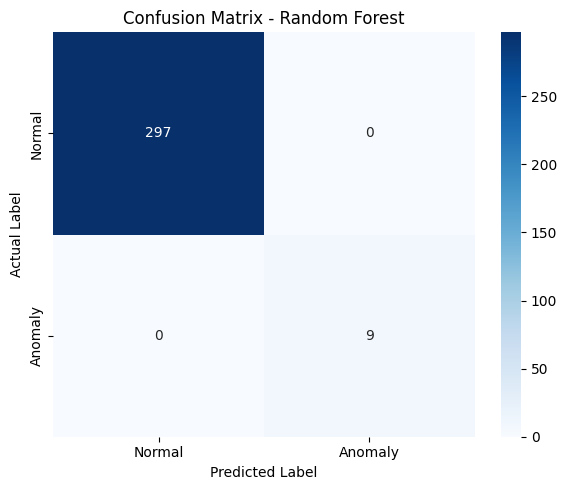


True Positives  (Anomaly correctly detected) : 9
True Negatives  (Normal correctly detected)  : 297
False Positives (Normal flagged as Anomaly)  : 0
False Negatives (Anomaly missed)             : 0


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

TP = cm[1][1]; FP = cm[0][1]
TN = cm[0][0]; FN = cm[1][0]
print(f"\nTrue Positives  (Anomaly correctly detected) : {TP}")
print(f"True Negatives  (Normal correctly detected)  : {TN}")
print(f"False Positives (Normal flagged as Anomaly)  : {FP}")
print(f"False Negatives (Anomaly missed)             : {FN}")

In [ ]:
print(classification_report(y_true, y_pred,
                             target_names=['Normal', 'Anomaly']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       297
     Anomaly       1.00      1.00      1.00         9

    accuracy                           1.00       306
   macro avg       1.00      1.00      1.00       306
weighted avg       1.00      1.00      1.00       306



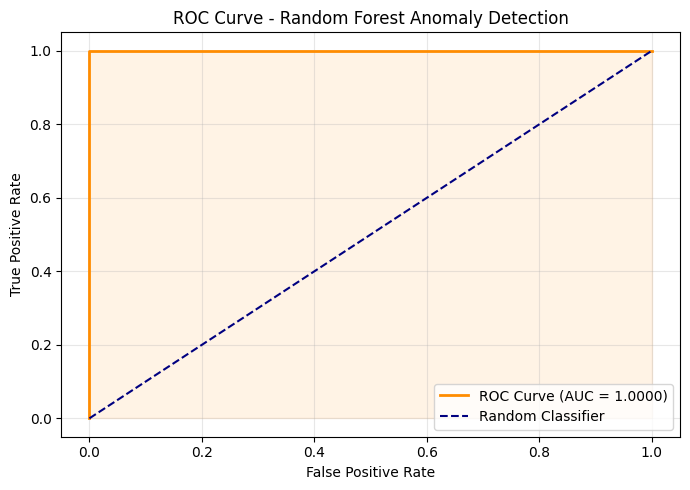

AUC Score : 1.0000


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Anomaly Detection')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score : {roc_auc:.4f}")

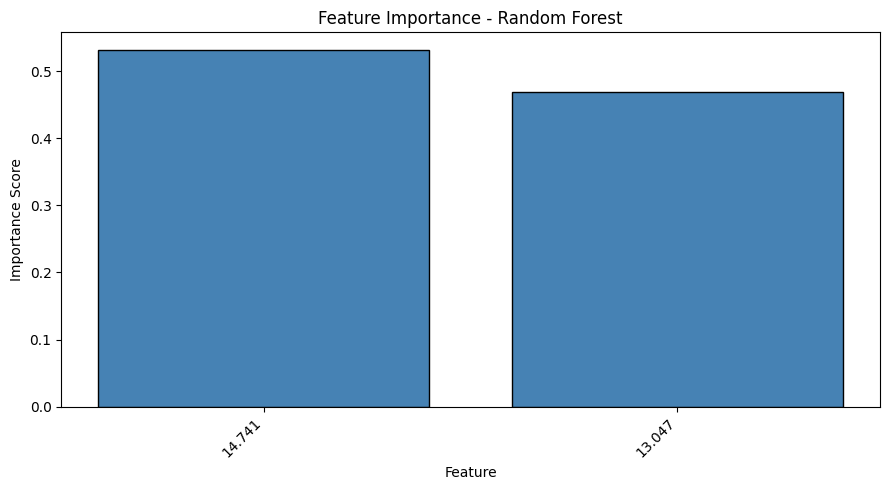

In [ ]:
feature_names       = tr_numeric.columns.tolist()
feature_importances = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(9, 5))
plt.bar(range(len(feature_names)),
        feature_importances[sorted_idx],
        color='steelblue', edgecolor='black')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in sorted_idx], rotation=45, ha='right')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

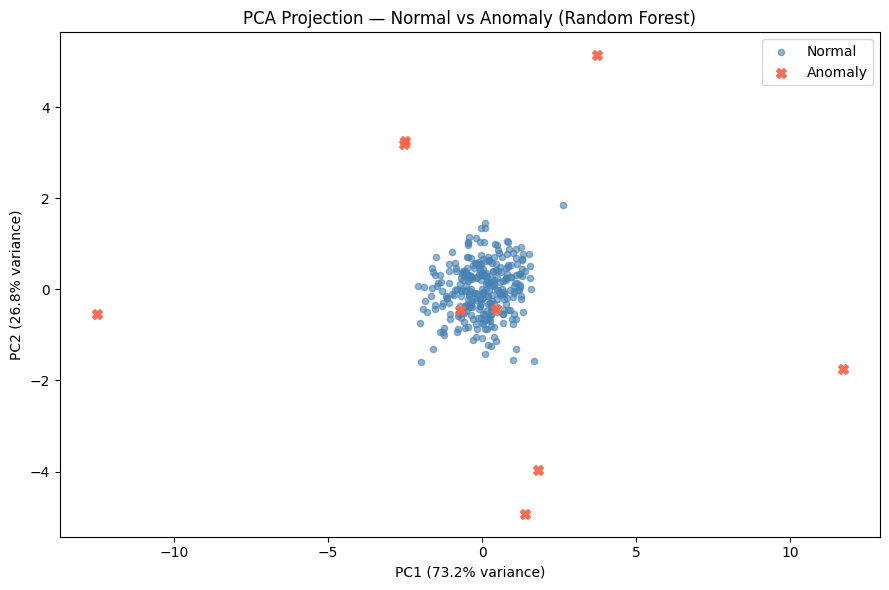

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_val_pca = pca.fit_transform(X_val_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(X_val_pca[y_pred == 0, 0], X_val_pca[y_pred == 0, 1],
            c='steelblue', label='Normal',  alpha=0.6, s=20)
plt.scatter(X_val_pca[y_pred == 1, 0], X_val_pca[y_pred == 1, 1],
            c='tomato',    label='Anomaly', alpha=0.9, s=50, marker='X')
plt.title('PCA Projection — Normal vs Anomaly (Random Forest)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (TP + TN) / (TP + TN + FP + FN)

print("=" * 50)
print("     ANOMALY DETECTION - FINAL SUMMARY")
print("=" * 50)
print(f"  Algorithm          : Random Forest")
print(f"  Trees in Forest    : 100")
print(f"  Total Val Samples  : {len(y_pred)}")
print(f"  Anomalies Detected : {np.sum(y_pred == 1)}")
print(f"  Accuracy           : {accuracy*100:.2f}%")
print(f"  Precision          : {precision:.4f}")
print(f"  Recall             : {recall:.4f}")
print(f"  F1 Score           : {f1:.4f}")
print(f"  AUC Score          : {roc_auc:.4f}")
print("=" * 50)

     ANOMALY DETECTION - FINAL SUMMARY
  Algorithm          : Random Forest
  Trees in Forest    : 100
  Total Val Samples  : 306
  Anomalies Detected : 9
  Accuracy           : 100.00%
  Precision          : 1.0000
  Recall             : 1.0000
  F1 Score           : 1.0000
  AUC Score          : 1.0000
